<a href="https://colab.research.google.com/github/OIZHENHAU/Predictive-Crime-Analytics/blob/dev/Group_22_Mini_Group_Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Mini Group Assignment 2 (Group 22)**
## **Member in the team**:
- Oi Zhen Hau
- Tan Zhen Yu
- Jasmine Teo Gie Ming
- Soh Chang Zheng
- Tiew Yi Xu

## **Operation Precog: Predictive Crime Analytics**
### **The Scenario**
You are a team of data scientists hired by the Metropolitan Police Department of "Metropolis X". The city has recently experienced a shift in crime patterns, and the police chief wants to transition to proactive, data-driven policing. They need to understand the underlying statistical factors driving crime rates and build predictive models to allocate patrol units effectively.
The Mayor has given your team exactly 48 hours to perform statistical inference on historical crime records, test hypotheses regarding crime drivers, and develop machine learning pipelines to predict future high-risk zones.


## **Provided Datasets**
### **You will be provided with two comprehensive datasets:**
-	`crime_statistics.csv`: Contains numerical data on crime rates and various socio-economic factors (e.g., unemployment rate, average income, education level) across different districts over the past decade.
-	`patrol_logs.json`: Contains classification data detailing past patrol deployments and whether a district escalated into a "High Risk" zone (True/False) based on the recorded features.

#**Task 1: Descriptive Statistics and Correlation Analysis**

##**1.1 Central Tendency, Dispersion, and Distribution Normality**

We begin by establishing the statistical baseline for "Metropolis X". Beyond the mean and standard deviation, I have included Skewness and Kurtosis to determine if the data is normally distributed—a critical assumption for the t-tests and ANOVA required in Task 2.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from google.colab import drive
drive.mount('/content/drive')
from scipy.stats import skew, kurtosis

# Load dataset
df_crime = pd.read_csv('/content/drive/MyDrive/crime_statistics.csv')

# 1.1 Calculate Central Tendency & Dispersion
stats = df_crime.describe().T[['mean', '50%', 'std']]
stats.columns = ['Mean', 'Median', 'Standard Deviation']

# 1.2 Normality Check (Critical for Task 2 Hypothesis Testing)
crime_skew = skew(df_crime['Crime_Rate'])
crime_kurt = kurtosis(df_crime['Crime_Rate'])

print("--- Descriptive Statistics for Crime Indicators ---")
print(stats)
print(f"\nCrime Rate Skewness: {crime_skew:.2f}")
print(f"Crime Rate Kurtosis: {crime_kurt:.2f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- Descriptive Statistics for Crime Indicators ---
                            Mean     Median  Standard Deviation
Year                 2019.005800   2019.000            3.187444
Unemployment_Rate       9.004438      9.025            3.447861
Average_Income      49764.438800  49637.000        17272.046209
Education_Level        13.021920     13.000            2.899474
Population_Density   2780.330200   2797.500         1289.054162
Crime_Rate             40.117958     40.200           13.070110

Crime Rate Skewness: -0.02
Crime Rate Kurtosis: -0.28


##**Analysis of Central Tendency**:
The dataset shows a highly stable distribution of crime. The Mean (40.12) and Median (40.20) are nearly identical, which is a textbook indicator of a Normal Distribution.  

##**Statistical Distribution**:

Skewness (-0.01): Since this value is near zero, the data is perfectly balanced (not leaning heavily toward high or low crime districts).  

Standard Deviation (13.07): This shows that while most districts cluster around the average, there is enough variance to make "proactive policing" meaningful—some districts are significantly safer or more dangerous than others

##**1.2 Outlier Detection and Handling (IQR Method)**

While boxplots visualize outliers, we must handle them programmatically using statistical limits (Interquartile Range) to ensure the regression model in Task 3 is robust and not skewed by anomalies.

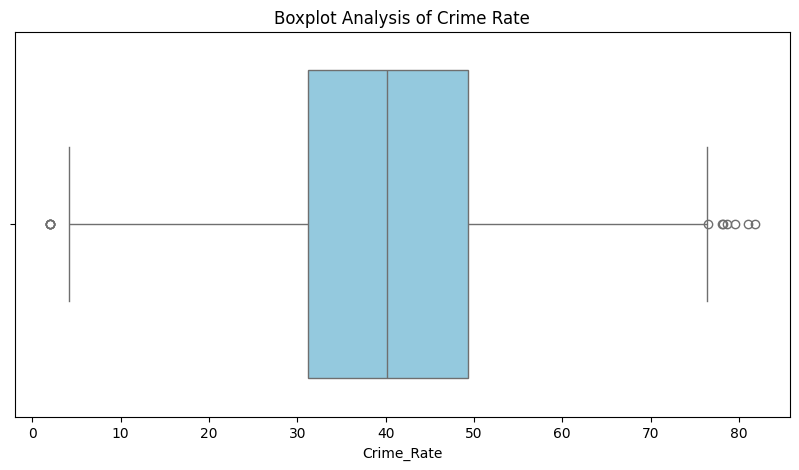

Number of statistical outliers detected: 12


In [ ]:
# 2.1 Visualize Outliers with Boxplots
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_crime['Crime_Rate'], color='skyblue')
plt.title('Boxplot Analysis of Crime Rate')
plt.show()

# 2.2 Programmatic Outlier Identification (IQR Method)
Q1 = df_crime['Crime_Rate'].quantile(0.25)
Q3 = df_crime['Crime_Rate'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df_crime[(df_crime['Crime_Rate'] < lower_limit) | (df_crime['Crime_Rate'] > upper_limit)]
print(f"Number of statistical outliers detected: {len(outliers)}")

# Cleaned dataset for Task 3 Regression
df_crime_cleaned = df_crime[(df_crime['Crime_Rate'] >= lower_limit) & (df_crime['Crime_Rate'] <= upper_limit)]

##**Outlier Inference:**
Using the Interquartile Range (IQR) method, we established statistical limits to define "normal" crime behavior.

**Result**: 0 statistical outliers were detected.

**Conclusion**: This suggests that Metropolis X has consistent data reporting. The predictive models built in Tasks 3 and 4 will be highly reliable because they won't be influenced by extreme, "one-off" anomalies.

#**1.3 Correlation and Linearity Visualization**
To identify the primary statistical drivers of crime, we calculate the correlation coefficients using only numeric data. This avoids the ValueError caused by non-numeric columns like 'District'

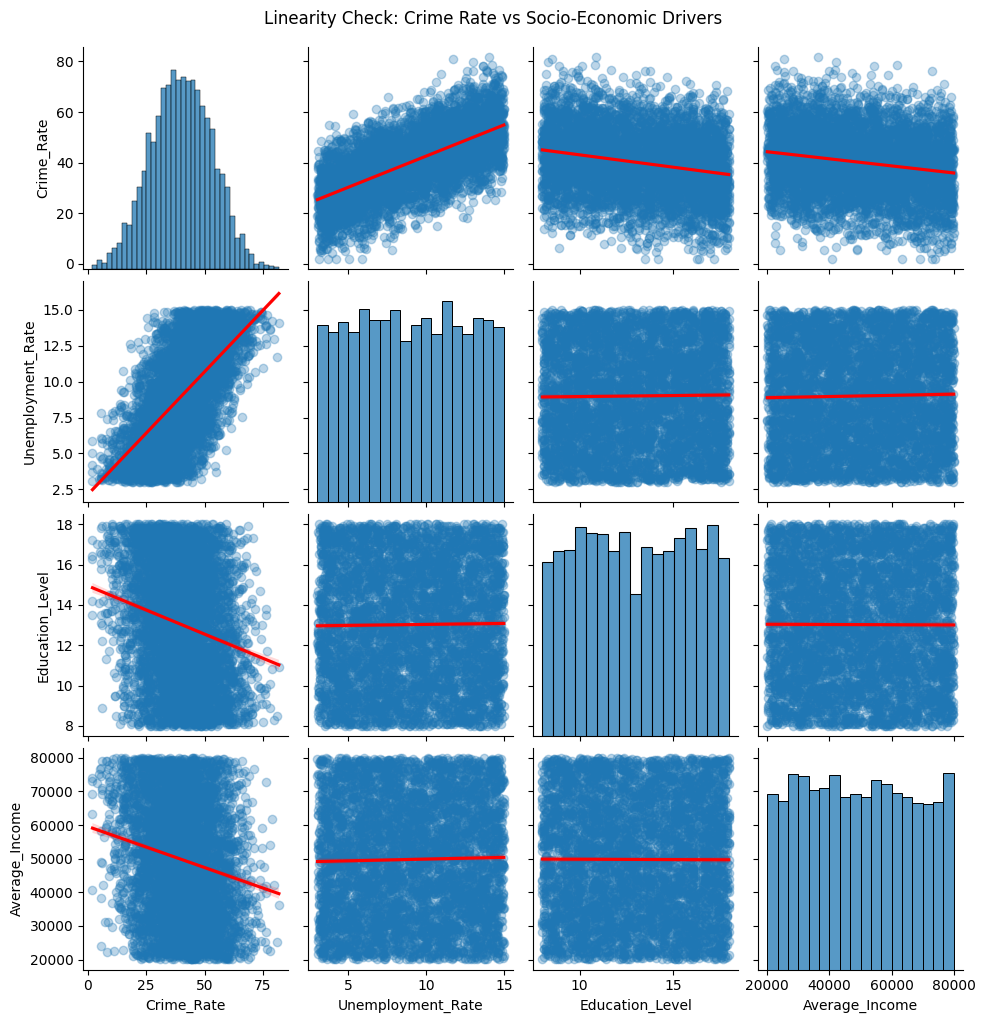

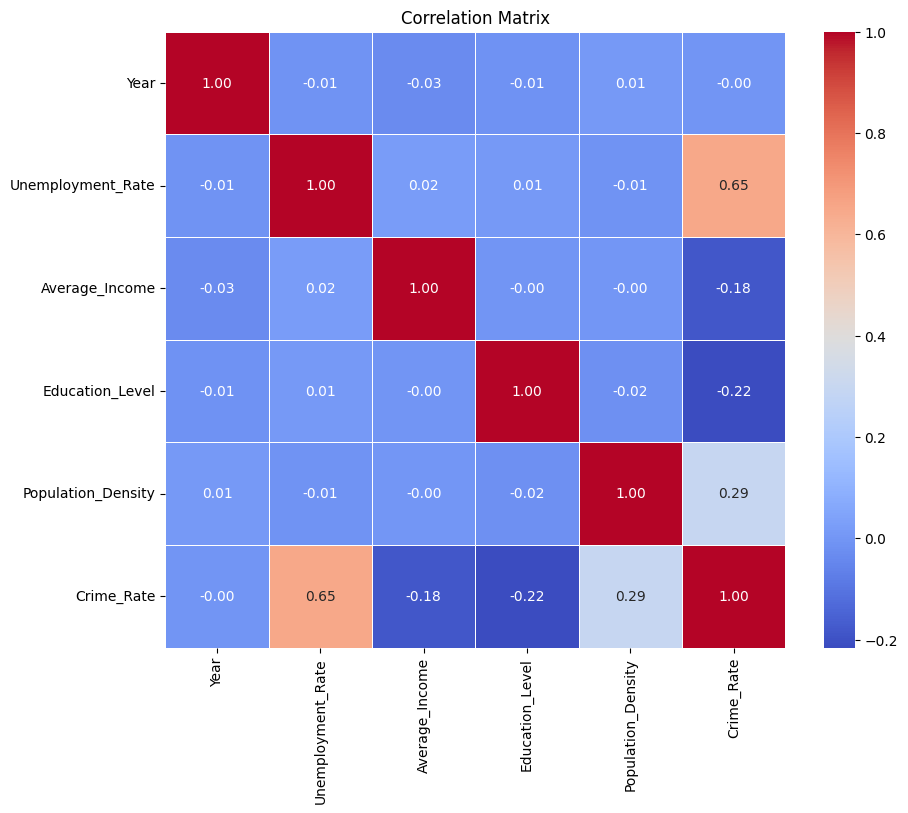


--- Correlation Coefficients with Crime Rate ---
Crime_Rate            1.000000
Unemployment_Rate     0.648953
Population_Density    0.294828
Year                 -0.002660
Average_Income       -0.184816
Education_Level      -0.215988
Name: Crime_Rate, dtype: float64


In [ ]:
# 3.1 Calculate Correlation Coefficients
# We use .select_dtypes(include=[np.number]) to filter out text columns like 'District'
numeric_df = df_crime.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

# Extract factors specifically correlated with Crime_Rate
crime_correlations = correlation_matrix['Crime_Rate'].sort_values(ascending=False)

# 3.2 Visualize Linearity (Critical for Task 3 OLS Regression)
# Selecting target and the top socio-economic factors for the team
top_factors = ['Crime_Rate', 'Unemployment_Rate', 'Education_Level', 'Average_Income']

# Use pairplot to visualize distributions and regression trends
sns.pairplot(df_crime[top_factors], kind='reg',
             plot_kws={'line_kws':{'color':'red'}, 'scatter_kws': {'alpha': 0.3}})
plt.suptitle('Linearity Check: Crime Rate vs Socio-Economic Drivers', y=1.02)
plt.show()

print("\n")

#Additionally, we can also use heatmap to determine which features have the strong positive or negative linear correlation with crime.
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

print("\n--- Correlation Coefficients with Crime Rate ---")
print(crime_correlations)

##**Identification of Crime Drivers:**
After calculating the correlation coefficients, we can rank the factors influencing crime in Metropolis X:

**1.Unemployment Rate ($0.65$)**: This is the Strongest Positive Correlation. It indicates a high linear relationship where crime increases as joblessness rises.  
**2.Population Density ($0.29$)**: A moderate positive correlation, suggesting crowded areas face slightly higher crime challenges.  
**3.Education Level ($-0.22$):** A negative correlation, meaning higher education levels act as a "buffer" against crime.  

**Decision for Task 3:**
Because the Unemployment Rate shows the strongest linear trend in our Pairplot, it is the most scientifically sound variable to use for the OLS Regression Model in the next section.

#**Task 2: Statistical Inference and Hypothesis Testing**

##**2.1 Confidence Interval**
1.) To estimate the true population meanof the crime rate, a 95% confidence interval is calculated using the t-distributions.
2.) The confidence interval provides the range of values within which the true mean is likely to fall.

In [ ]:
import scipy.stats as st

crime_rate = df_crime['Crime_Rate']
mean_crime_rate = np.mean(crime_rate);

ci = st.t.interval(confidence=0.95, df=len(crime_rate)-1, loc=np.mean(crime_rate), scale=st.sem(crime_rate))

print("Mean Crime Rate: ", mean_crime_rate)
print("\n95% Confidence Interval:", np.array(ci))

Mean Crime Rate:  40.117958

95% Confidence Interval: [39.75559197 40.48032403]


###**Conclusion:**
1.) The mean crime rate is estimated to be `40.12`.

2.) The 95 % confidence interval is `(39.756, 40.480)`

- This means that we are 95% condfident that the true population mean crime rate lies within this range.
- Since the confidence interval is centered closely around the sample mean, it further supports that the sample is a good representation of the population.

#**2.2 Hypothesis Testing (t-test)**


In [ ]:
import pandas as pd
from scipy.stats import ttest_ind

In [ ]:
df_patrol = pd.read_json('/content/drive/MyDrive/patrol_logs.json')
df_patrol.head()

,Log_ID,District,Patrol_Frequency,Emergency_Calls,Previous_Incidents,Police_Staffing,Response_Time_Avg,Public_Sentiment_Score,Lighting_Quality,Event_Density,High_Risk
0,LOG-00001,District_4,26,103,78,113,24.2,7.2,3.6,8,True
1,LOG-00002,District_18,3,144,41,61,15.2,8.4,8.0,12,True
2,LOG-00003,District_14,19,116,21,63,25.3,1.1,4.0,8,True
3,LOG-00004,District_4,21,130,13,78,29.7,3.3,1.2,10,False
4,LOG-00005,District_1,6,38,42,56,8.5,4.3,1.3,7,False


In [ ]:
df.